# EDA: the data-quality findings behind the modeling cohort

The NASA PCoE battery set ships 34 batteries, but only 12 are used in this project
(4 canonical + 8 train-only) and only 4 define validation/test. This notebook walks
through the anomaly hunt that produced that decision.

This is exploration scratch paper: the **conclusions live in code**
(`src/data/splits.py` documents a reason per excluded battery, and the last cell
asserts this notebook and that module agree). Nothing here ships.

Prerequisite: `python -m src.data.parse_nasa` has been run, so
`data/processed/cycles.parquet` exists.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

RATED_AH = 2.0
EOL_SOH = 0.70
INK, MUTED, GRID = "#1F2733", "#5B6472", "#E5E8EC"
PALETTE = ["#3B6EC5", "#C2571B", "#5B8A3C", "#7A5FB8"]


def style(ax):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED, labelsize=9)


def label_end(ax, x, y, text, color):
    ax.annotate(text, (x, y), textcoords="offset points", xytext=(6, 0),
                fontsize=9, color=color, va="center")


cycles = pd.read_parquet(ROOT / "data/processed/cycles.parquet")
cycles["soh"] = cycles["capacity_ah"] / RATED_AH
print(f"{cycles.battery_id.nunique()} batteries, {len(cycles)} discharge rows")

34 batteries, 2750 discharge rows


## The healthy reference: the canonical FY08Q4 batch

B0005/B0006/B0007/B0018 were cycled at 24 C with one consistent protocol
(2 A constant-current discharge) all the way to ~30% fade. Their capacity traces
are what an SoH signal is supposed to look like: monotonic fade plus the
well-known regeneration spikes after rest periods. Everything below gets judged
against this shape.

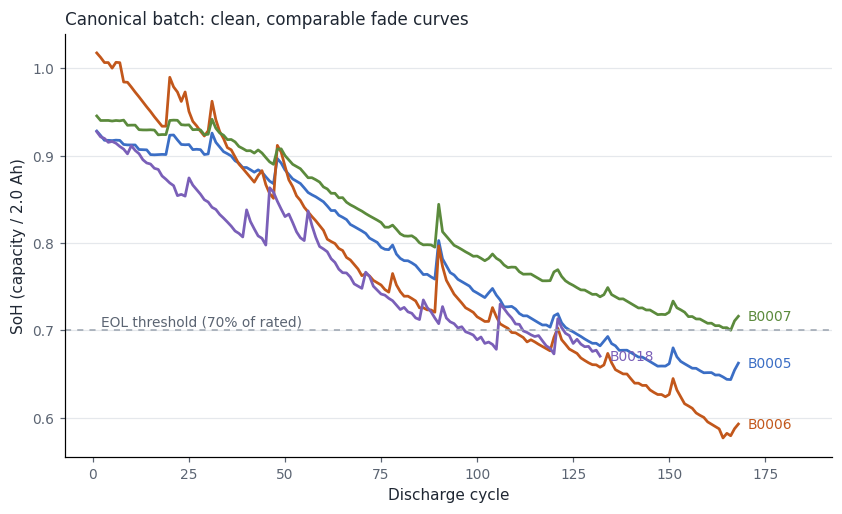

In [2]:
CANONICAL = ["B0005", "B0006", "B0007", "B0018"]
fig, ax = plt.subplots(figsize=(9, 5), dpi=110)
for bid, color in zip(CANONICAL, PALETTE):
    g = cycles[cycles.battery_id == bid]
    ax.plot(g.cycle_index, g.soh, linewidth=1.8, color=color)
    label_end(ax, g.cycle_index.iloc[-1], g.soh.iloc[-1], bid, color)
ax.axhline(EOL_SOH, color="#9AA3AF", linewidth=1, linestyle=(0, (4, 4)))
ax.text(2, EOL_SOH + 0.005, "EOL threshold (70% of rated)", fontsize=9, color=MUTED)
ax.set_xlim(right=ax.get_xlim()[1] + 16)
ax.set_xlabel("Discharge cycle", color=INK)
ax.set_ylabel("SoH (capacity / 2.0 Ah)", color=INK)
ax.set_title("Canonical batch: clean, comparable fade curves", loc="left", fontsize=11, color=INK)
style(ax)
plt.show()

## Whole-fleet audit

One row per battery: cycle count, SoH at first/last cycle, extremes, and the
ambient temperatures seen. The `flags` column is the anomaly checklist that
drove the rest of this notebook.

In [3]:
audit = cycles.groupby("battery_id").agg(
    n=("cycle_index", "size"),
    soh_first=("soh", "first"),
    soh_last=("soh", "last"),
    soh_min=("soh", "min"),
    soh_max=("soh", "max"),
    ambient_temps=("ambient_temperature", lambda s: sorted(set(s))),
).round(3)


def flags(row):
    out = []
    if row.soh_max > 1.005:
        out.append("SoH > 1 (impossible)")
    if row.soh_first < EOL_SOH:
        out.append("below EOL at first cycle")
    if row.soh_min < 0.2:
        out.append("near-zero capacity runs")
    if len(row.ambient_temps) > 1:
        out.append("ambient changes mid-experiment")
    if row.n < 30:
        out.append("very short run")
    return "; ".join(out)


audit["flags"] = audit.apply(flags, axis=1)
audit

,n,soh_first,soh_last,soh_min,soh_max,ambient_temps,flags
battery_id,,,,,,,
B0005,168,0.928,0.663,0.644,0.928,[24.0],
B0006,168,1.018,0.593,0.577,1.018,[24.0],SoH > 1 (impossible)
B0007,168,0.946,0.716,0.700,0.946,[24.0],
B0018,132,0.928,0.671,0.671,0.928,[24.0],
B0025,28,0.924,0.884,0.884,0.924,[24.0],very short run
B0026,28,0.907,0.884,0.693,0.908,[24.0],very short run
B0027,28,0.912,0.885,0.885,0.912,[24.0],very short run
B0028,28,0.902,0.859,0.859,0.902,[24.0],very short run
B0029,40,0.849,0.806,0.806,0.922,[43.0],


## Finding 1: physically impossible SoH (B0036, B0049-B0051)

A 2.0 Ah rated cell cannot deliver SoH 1.19-1.32 (2.4-2.6 Ah). The B0049-B0052
batch is the worst offender, and NASA's own README for it says why it cannot be
trusted:

> "The experiments were carried out until the experiment control software
> crashed. Note that there are several discharge runs where the capacity as well
> as voltage levels were very low. Reasons for this have not been fully analyzed."

The traces swing between impossible highs and near-zero lows -- this is
instrumentation failure, not degradation.

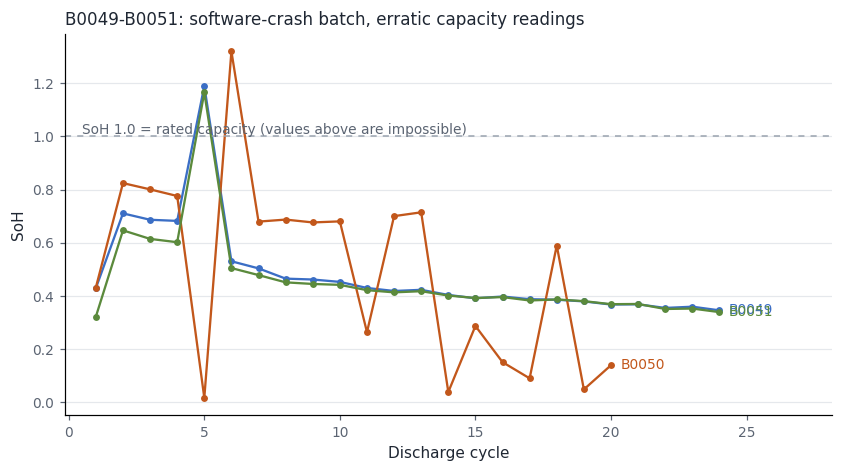

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
for bid, color in zip(["B0049", "B0050", "B0051"], PALETTE):
    g = cycles[cycles.battery_id == bid]
    ax.plot(g.cycle_index, g.soh, linewidth=1.5, color=color, marker="o", markersize=3.5)
    label_end(ax, g.cycle_index.iloc[-1], g.soh.iloc[-1], bid, color)
ax.axhline(1.0, color="#9AA3AF", linewidth=1, linestyle=(0, (4, 4)))
ax.text(0.5, 1.01, "SoH 1.0 = rated capacity (values above are impossible)", fontsize=9, color=MUTED)
ax.set_xlim(right=ax.get_xlim()[1] + 3)
ax.set_xlabel("Discharge cycle", color=INK)
ax.set_ylabel("SoH", color=INK)
ax.set_title("B0049-B0051: software-crash batch, erratic capacity readings", loc="left", fontsize=11, color=INK)
style(ax)
plt.show()

## Finding 2: near-zero capacity rows are aborted discharges, not dead cells

Several batteries log capacities near zero mid-life and then recover -- cells do
not do that. The tell is the minimum voltage reached during those discharges: a
completed run ends at the protocol cutoff (2.0-2.7 V depending on battery), while
the near-zero rows stop at ~2.9-3.8 V, i.e. the discharge never finished, so the
logged "capacity" measures nothing.

(The parser already drops the 19 rows where capacity is exactly 0.0 for the same
reason -- see the handling note in `src/data/parse_nasa.py`. The rows below are
the small-but-nonzero cousins that survive parsing and would poison a target.)

near-zero (SoH < 0.2) rows per battery:
battery_id
B0041    42
B0042    46
B0043    46
B0044    46


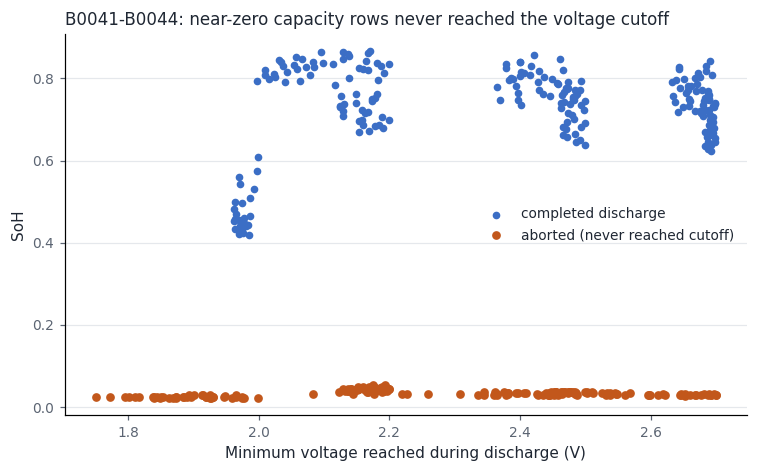

In [5]:
batch = cycles[cycles.battery_id.isin(["B0041", "B0042", "B0043", "B0044"])]
aborted = batch[batch.soh < 0.2]
complete = batch[batch.soh >= 0.2]
print("near-zero (SoH < 0.2) rows per battery:")
print(aborted.groupby("battery_id").size().to_string())

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=110)
ax.scatter(complete.voltage_min, complete.soh, s=16, color=PALETTE[0], label="completed discharge")
ax.scatter(aborted.voltage_min, aborted.soh, s=22, color=PALETTE[1], label="aborted (never reached cutoff)")
ax.set_xlabel("Minimum voltage reached during discharge (V)", color=INK)
ax.set_ylabel("SoH", color=INK)
ax.set_title("B0041-B0044: near-zero capacity rows never reached the voltage cutoff", loc="left", fontsize=11, color=INK)
legend = ax.legend(loc="center right", fontsize=9, frameon=False)
for text in legend.get_texts():
    text.set_color(INK)
style(ax)
plt.show()

## Finding 3: 4 C operation puts cells "past EOL" from birth

Capacity is temperature-dependent: a healthy cell discharged at 4 C delivers far
less than rated. Under the project's SoH definition (capacity / rated) the cold
batches sit below the 70% EOL threshold from their very first cycle -- so "cycles
until SoH crosses 70%" is answered before the experiment starts, and RUL is
ill-posed. Their fade signal is real but conflated with temperature; they are
excluded rather than patched with a per-temperature SoH definition.

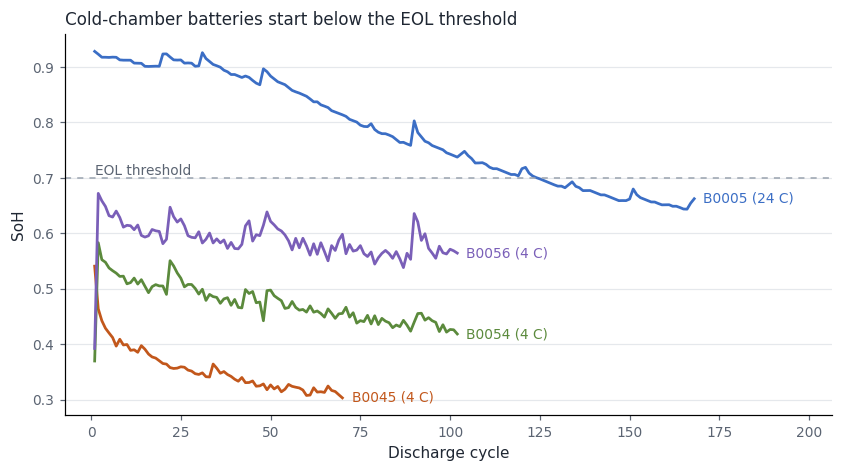

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
for bid, color, note in [
    ("B0005", PALETTE[0], "24 C"),
    ("B0045", PALETTE[1], "4 C"),
    ("B0054", PALETTE[2], "4 C"),
    ("B0056", PALETTE[3], "4 C"),
]:
    g = cycles[cycles.battery_id == bid]
    ax.plot(g.cycle_index, g.soh, linewidth=1.8, color=color)
    label_end(ax, g.cycle_index.iloc[-1], g.soh.iloc[-1], f"{bid} ({note})", color)
ax.axhline(EOL_SOH, color="#9AA3AF", linewidth=1, linestyle=(0, (4, 4)))
ax.text(1, EOL_SOH + 0.006, "EOL threshold", fontsize=9, color=MUTED)
ax.set_xlim(right=ax.get_xlim()[1] + 30)
ax.set_xlabel("Discharge cycle", color=INK)
ax.set_ylabel("SoH", color=INK)
ax.set_title("Cold-chamber batteries start below the EOL threshold", loc="left", fontsize=11, color=INK)
style(ax)
plt.show()

## Finding 4: mixed protocols make capacity incomparable across cycles

B0038-B0040 were cycled at *multiple* load currents (1/2/4 A) and *two* ambient
temperatures (24 and 44 C), per NASA's README. Measured capacity depends on both,
so the trace jumps between protocol regimes -- it is a protocol signal, not an
aging signal. The same argument (fixed but different loads/cutoffs per battery,
4 A vs 2 A) applies to B0033/B0034 vs the canonical cohort.

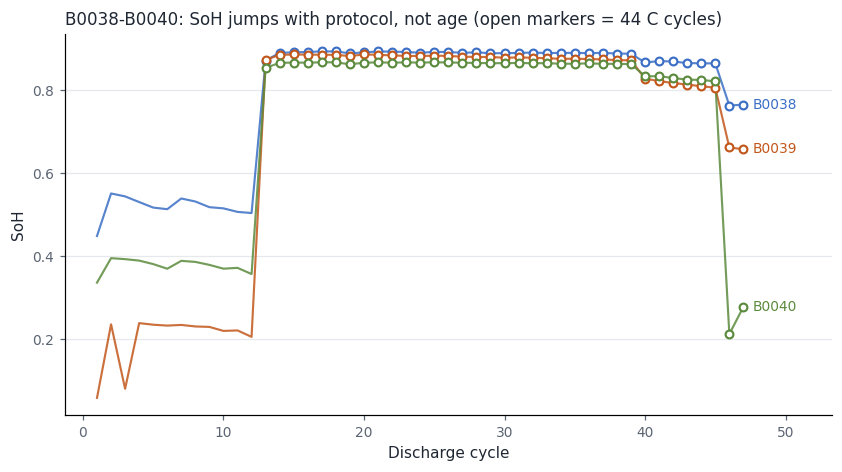

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
for bid, color in zip(["B0038", "B0039", "B0040"], PALETTE):
    g = cycles[cycles.battery_id == bid]
    ax.plot(g.cycle_index, g.soh, linewidth=1.4, color=color, alpha=0.85)
    hot = g[g.ambient_temperature > 30]
    ax.scatter(hot.cycle_index, hot.soh, s=26, facecolors="white", edgecolors=color, linewidths=1.4, zorder=5)
    label_end(ax, g.cycle_index.iloc[-1], g.soh.iloc[-1], bid, color)
ax.set_xlim(right=ax.get_xlim()[1] + 4)
ax.set_xlabel("Discharge cycle", color=INK)
ax.set_ylabel("SoH", color=INK)
ax.set_title("B0038-B0040: SoH jumps with protocol, not age (open markers = 44 C cycles)", loc="left", fontsize=11, color=INK)
style(ax)
plt.show()

## Conclusion: the cohort

| Group | Batteries | Decision |
|---|---|---|
| Canonical 24 C, consistent 2 A protocol, full fade | B0005, B0006, B0007, B0018 | val/test universe (val=B0007, test=B0018) + train |
| Consistent protocol, short/mild fade | B0025-B0028 (24 C), B0029-B0032 (43 C) | train-only augmentation |
| Mixed loads/cutoffs, impossible or anomalous readings, 4 C below-threshold, software crash | the other 22 | excluded, reason documented per battery |

The cell below asserts this notebook's fleet and `src/data/splits.py` agree, so
the exploration cannot silently drift from the shipped decision.

In [8]:
from src.data.splits import (
    EXCLUDED_BATTERIES,
    SPLIT_OF,
    TEST_BATTERIES,
    TRAIN_BATTERIES,
    VAL_BATTERIES,
)

present = set(cycles.battery_id)
assert present == set(SPLIT_OF) | set(EXCLUDED_BATTERIES), "cohort decision out of sync with data"
print(f"train ({len(TRAIN_BATTERIES)}): {list(TRAIN_BATTERIES)}")
print(f"val: {list(VAL_BATTERIES)}   test: {list(TEST_BATTERIES)}")
print(f"excluded: {len(EXCLUDED_BATTERIES)} batteries\n")
pd.Series(EXCLUDED_BATTERIES, name="exclusion reason").to_frame()

train (10): ['B0005', 'B0006', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032']
val: ['B0007']   test: ['B0018']
excluded: 22 batteries



,exclusion reason
B0033,4 A discharge to 2.0 V; capacity not comparabl...
B0034,4 A discharge to 2.2 V; capacity not comparabl...
B0036,capacity readings exceed rated by 22 percent; ...
B0038,load current and ambient temperature change ac...
B0039,load current and ambient temperature change ac...
B0040,load current and ambient temperature change ac...
B0041,4 C ambient with mixed 4 A / 1 A loads; NASA-f...
B0042,"4 C ambient, mixed loads; NASA-flagged unexpla..."
B0043,"4 C ambient, mixed loads; NASA-flagged unexpla..."
B0044,"4 C ambient, mixed loads; NASA-flagged unexpla..."
